**SNN Basics**

**First Step - Define Single Neuron Model For NPU(Neuromorphic Processing Unit SNN)**

In [25]:
# Spiking Neuron Model
# Define inputs, weights for inputs, decay constant, firing threshold

class Spike_neuron():
    def __init__(self, weights, decay_c, fire_thresh, cooldown_thresh):
        self.potential = 0                      # Current Potential in the Neuron Body
        self.weights = weights                  # Weights for each input from previous layer
        self.decay_c = decay_c                  # Decay constant which represents how fast the potential drops back to resting
        self.fire_thresh = fire_thresh          # Threshold at which the neuron fires to the next neurons in the next layer
        self.output = 0                         # Output signal of this neuron(firing signal)
        self.cooldown_thresh = cooldown_thresh  # Cooldown timer, usually brain neurons after firing have a set period for which they cannot fire
        self.counter = 0                        # The counter to enforce this timing delay between subsequent spikes
    
    def accumulate(self, inputs):
        # If the neuron is in resting state(cooldown) then no inputs are recieved
        # If the neuron is accepting inputs then it is is the matrix product of the inputs with the weights to obtain a single value which is added and checked with potential
        # If the potential is high enough then se fire for this neuron
        if self.counter > 0:
            self.output = 0
            self.counter -= 1
        else:
            potential_gain = inputs.T @ self.weights
            self.potential += potential_gain
            if(self.potential >= self.fire_thresh):
                self.fire()
        self.decay()
    
    def decay(self):
        # At each time step, the neuron is constantly losing potential and returning to resting potential(0)
        self.potential = self.potential - self.decay_c * self.potential
    
    def fire(self):
        # Firing involves setting the output to 1, setting potential back to 0, and setting a counter for cooldown
        self.output = 1
        self.potential = 0
        self.counter = self.cooldown_thresh


**Second Step - Define a layer of neurons which is a level of abstraction higher than a single neuron**

In [45]:
class Spike_Layer():
    def __init__(self, num_neuron, weights_v, decay_c_v, fire_thresh_v, cooldown_thresh_v):
        self.num_neuron = num_neuron
        self.weights_v = weights_v
        self.decay_c_v = decay_c_v
        self.fire_thresh_v = fire_thresh_v
        self.cooldown_thresh_v = cooldown_thresh_v
        self.neuron_list = []

    def initialize_neurons(self):
        for i in range(self.num_neuron):
            self.neuron_list.append(Spike_neuron(self.weights_v[i], self.decay_c_v[i], self.fire_thresh_v[i], self.cooldown_thresh_v[i]))

    def signal_prop(self, input_v):
        for i in range(len(self.neuron_list)):
            self.neuron_list[i].accumulate(np.array([input_v[0][i]]))


# Plotting and Testing Codes

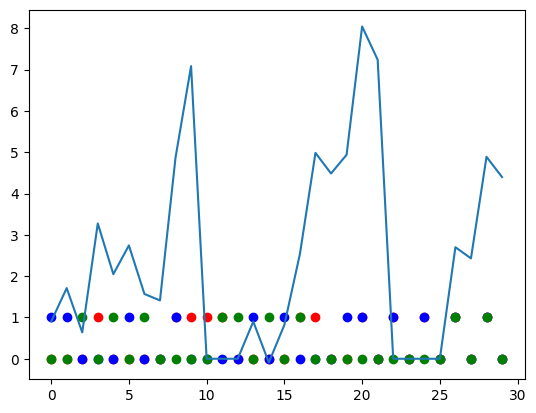

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Single Input to neuron mapped

weights = [3, 1, -1]
decay_c = 0.1
fire_thresh = 10
cooldown_thresh = 2

n1 = Spike_neuron(weights, decay_c, fire_thresh, cooldown_thresh)

input1 = [0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,0, 1, 0, 1, 0]
input2 = [1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,0, 1, 0, 1, 0]
input3 = [0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,0, 1, 0, 1, 0]

potentials = []
for i in range(len(input1)):
    n1.accumulate(np.array([input1[i], input2[i], input3[i]]))
    potentials.append(n1.potential)

x_s = np.arange(0,len(potentials), 1)

plt.plot(x_s, potentials)
plt.scatter(x_s, input1, c='red')
plt.scatter(x_s, input2, c='blue')
plt.scatter(x_s, input3, c='green')

In [54]:
# Spike Layer Probing/Testing

weights = [[3], [2], [1]]
decay_c = [0.1, 0.2, 0.05]
fire_thresh = [10, 5, 6]
cooldown_thresh = [2, 1, 3]

input1 = [[0,0,0], [0,0,0], [0,0,0], [1,1,1], [0,0,0], [0,0,0], [0,0,0], [0,0,0], [1,1,1], [1,1,1], [1,1,1], [1,1,1], [0,0,0], [0,0,0], [0,0,0], [0,0,0], [1,1,1], [1,1,1], [0,0,0], [0,0,0], [1,1,1], [0,0,0], [1,1,1], [0,0,0], [1,1,1],[0,0,0], [1,1,1], [0,0,0], [1,1,1], [0,0,0]]

l1 = Spike_Layer(3, weights, decay_c, fire_thresh, cooldown_thresh)
l1.initialize_neurons()

potentials_1 = []
potentials_2 = []
potentials_3 = []

for i in range(len(input1)):
    l1.signal_prop(np.array([input1[i]]))
    potentials_1.append(l1.neuron_list[0].potential)
    potentials_2.append(l1.neuron_list[1].potential)
    potentials_3.append(l1.neuron_list[2].potential)
    

x_s = np.arange(0,len(potentials_1), 1)

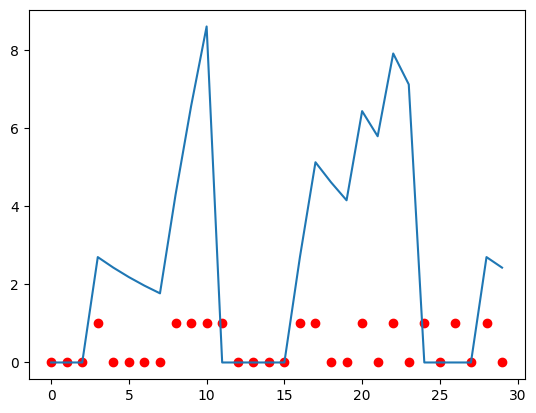

In [55]:
plt.plot(x_s, potentials_1)
input_plt_1 = []
for i in range(len(input1)):
    input_plt_1.append(input1[i][0])
plt.scatter(x_s, input_plt_1, c='red')

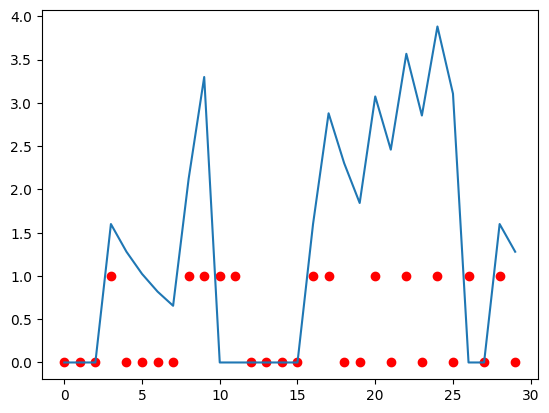

In [56]:
plt.plot(x_s, potentials_2)
input_plt_2 = []
for i in range(len(input1)):
    input_plt_2.append(input1[i][1])
plt.scatter(x_s, input_plt_2, c='red')

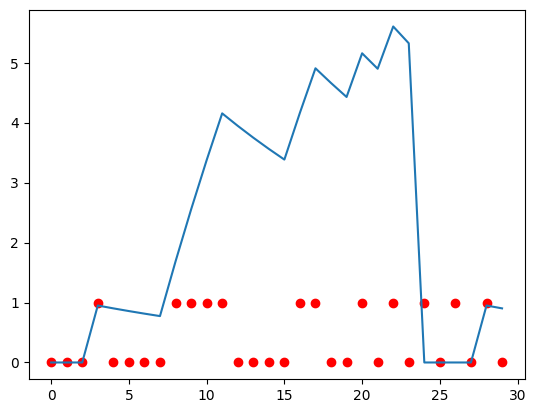

In [57]:
plt.plot(x_s, potentials_3)
input_plt_3 = []
for i in range(len(input1)):
    input_plt_3.append(input1[i][0])
plt.scatter(x_s, input_plt_3, c='red')